In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install owlready2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 16.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for owlready2: filename=owlready2-0.51-cp313-cp313-linux_x86_64.whl size=24764652 sha256=1fe1b58bb566258c9f2cadc8eb91c024872d6b3f3c1cd0536d70518403646fd3
  Stored in directory: /root/.cache/pip/wheels/cc/16/52/762fdfa8c53f256db44674790a3ceba702c3c763c96ce8b62c
Successfully built owlready2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import owlready2 as or2
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
onto = or2.get_ontology("/path/to/ontology/mlprov.owx").load()
with onto:
    class description(or2.DataProperty):
        range = [str]

* Owlready2 * WARNING: ObjectProperty http://www.w3.org/ns/prov#wasRevisionOf belongs to more than one entity types: [owl.AnnotationProperty, owl.ObjectProperty, prov.wasDerivedFrom]; I'm trying to fix it...
* Owlready2 * WARNING: ObjectProperty http://www.w3.org/ns/prov#specializationOf belongs to more than one entity types: [owl.AnnotationProperty, owl.ObjectProperty, prov.alternateOf]; I'm trying to fix it...


In [ ]:
train_data = onto["training_dataset"]
test_data = onto["testing_dataset"]
onto_model = onto["model"]
hyperparameter = onto["hyperparameter"]
performance_metric = onto["performance_metric"]

In [ ]:
csv_file_path = "/path/to/data/Student_Performance.csv"
df = pd.read_csv(csv_file_path)
df = df.dropna()
df.head()

# Separate features (X) and target (y) before splitting
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv('/path/to/data/train.csv', index=False)

test_df = pd.concat([X_test, y_test], axis=1)
test_df.to_csv('/path/to/data/test.csv', index=False)

In [ ]:
training_dataset = train_data("train.csv")
training_dataset.description = ["Location: https://github.com/AnonymousWriter1/BiasProvenance"]
testing_dataset = test_data("test.csv")
testing_dataset.description = ["Location: https://github.com/AnonymousWriter1/BiasProvenance"]

In [ ]:
le = LabelEncoder()
X_train['Extracurricular Activities'] = le.fit_transform(X_train['Extracurricular Activities'])
X_test['Extracurricular Activities'] = le.transform(X_test['Extracurricular Activities'])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Lambda = 10

In [ ]:
lasso_model_10 = Lasso(alpha=10)
lasso_model_10.fit(X_train, y_train)
lasso_regression_model_10 = onto_model("lasso_regression_lambda=10")

In [ ]:
lasso_predictions_10 = lasso_model_10.predict(X_test)

lasso_r2_10 = r2_score(y_test, lasso_predictions_10)
print(f"Lasso Lambda=10 R-squared: {lasso_r2_10}")
lasso_regression_r2_10 = performance_metric(f"Lasso_regression_lambda=10_R2={lasso_r2_10}")

lasso_mse_10 = mean_squared_error(y_test, lasso_predictions_10)
print(f"Lasso Lambda=10 Mean Squared Error: {lasso_mse_10}")
lasso_regression_mse_10 = performance_metric(f"Lasso_regression_lambda=10_MSE={lasso_mse_10}")

Lasso Lambda=10 R-squared: 0.5659180707140168
Lasso Lambda=10 Mean Squared Error: 160.86430211794988


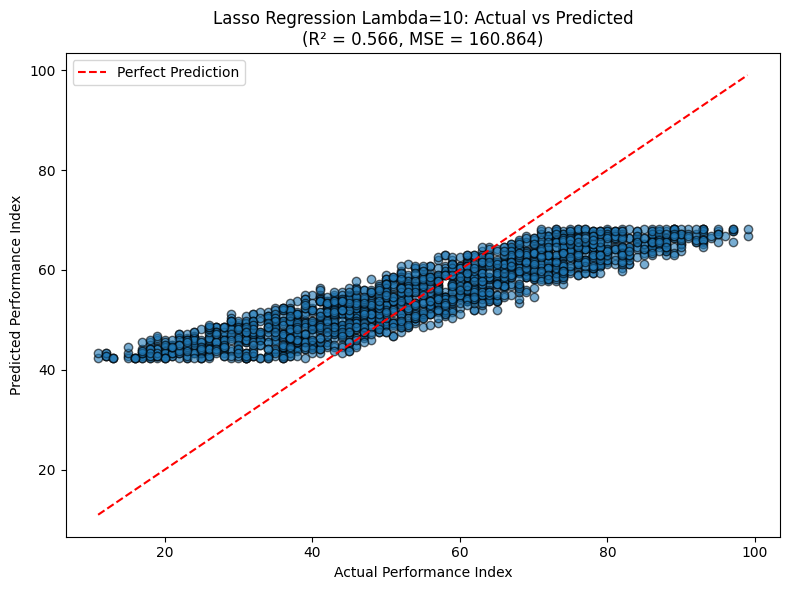

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lasso_predictions_10, alpha=0.6, edgecolor='k')

min_val = min(y_test.min(), lasso_predictions_10.min())
max_val = max(y_test.max(), lasso_predictions_10.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title(f'Lasso Regression Lambda=10: Actual vs Predicted\n(R² = {lasso_r2_10:.3f}, MSE = {lasso_mse_10:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

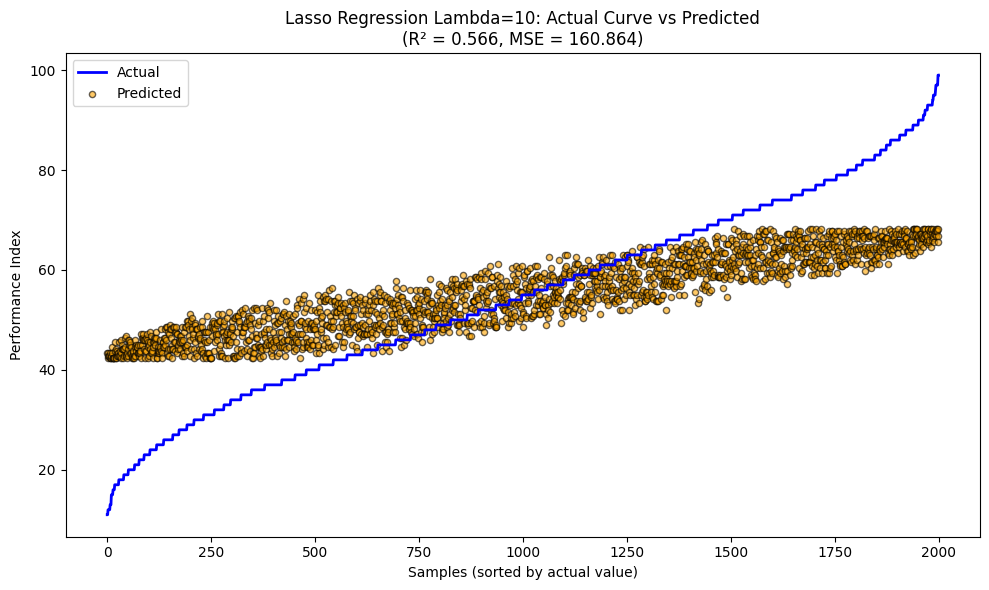

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sort_idx = np.argsort(y_test.values)
y_test_sorted = y_test.values[sort_idx]
predictions_sorted = lasso_predictions_10[sort_idx]

x_axis = np.arange(len(y_test_sorted))

plt.figure(figsize=(10, 6))
plt.plot(x_axis, y_test_sorted, color='blue', label='Actual', linewidth=2)
plt.scatter(x_axis, predictions_sorted, alpha=0.6, edgecolor='k', color='orange', label='Predicted', s=20)

plt.xlabel('Samples (sorted by actual value)')
plt.ylabel('Performance Index')
plt.title(f'Lasso Regression Lambda=10: Actual Curve vs Predicted\n(R² = {lasso_r2_10:.3f}, MSE = {lasso_mse_10:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# Lambda = 1

In [ ]:
lasso_model_1 = Lasso(alpha=1)
lasso_model_1.fit(X_train, y_train)
lasso_regression_model_1 = onto_model("lasso_regression_lambda=1")

In [ ]:
lasso_predictions_1 = lasso_model_1.predict(X_test)

lasso_r2_1 = r2_score(y_test, lasso_predictions_1)
print(f"Lasso Lambda=1 R-squared: {lasso_r2_1}")
lasso_regression_r2_1 = performance_metric(f"Lasso_regression_lambda=1_R2={lasso_r2_1}")

lasso_mse_1 = mean_squared_error(y_test, lasso_predictions_1)
print(f"Lasso Lambda=1 Mean Squared Error: {lasso_mse_1}")
lasso_regression_mse_1 = performance_metric(f"Lasso_regression_lambda=1_MSE={lasso_mse_1}")

Lasso Lambda=1 R-squared: 0.9797163665115288
Lasso Lambda=1 Mean Squared Error: 7.516812669226591


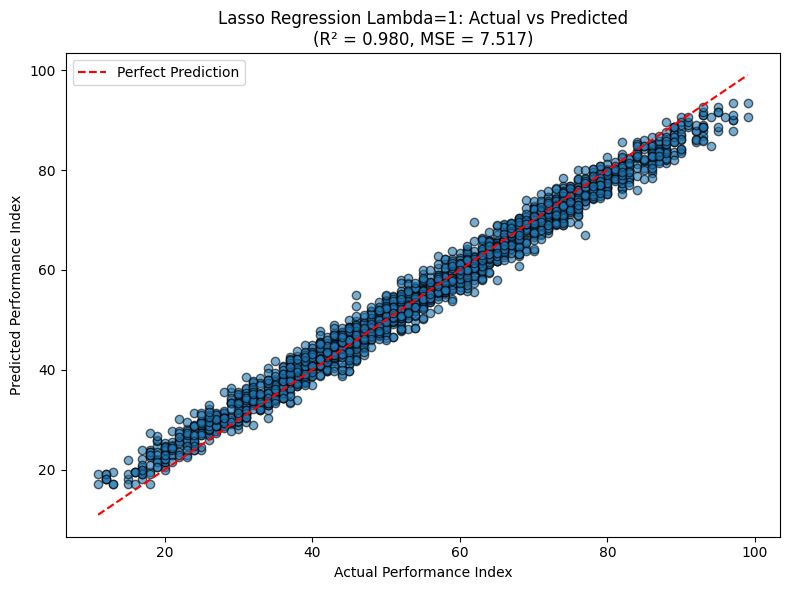

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lasso_predictions_1, alpha=0.6, edgecolor='k')

min_val = min(y_test.min(), lasso_predictions_1.min())
max_val = max(y_test.max(), lasso_predictions_1.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title(f'Lasso Regression Lambda=1: Actual vs Predicted\n(R² = {lasso_r2_1:.3f}, MSE = {lasso_mse_1:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

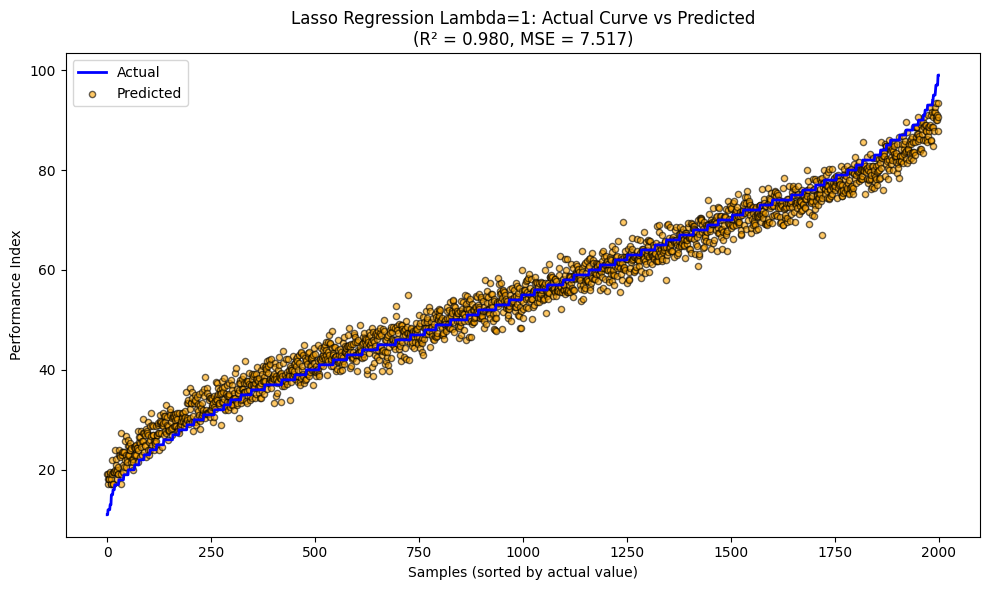

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sort_idx = np.argsort(y_test.values)
y_test_sorted = y_test.values[sort_idx]
predictions_sorted = lasso_predictions_1[sort_idx]

x_axis = np.arange(len(y_test_sorted))

plt.figure(figsize=(10, 6))
plt.plot(x_axis, y_test_sorted, color='blue', label='Actual', linewidth=2)
plt.scatter(x_axis, predictions_sorted, alpha=0.6, edgecolor='k', color='orange', label='Predicted', s=20)

plt.xlabel('Samples (sorted by actual value)')
plt.ylabel('Performance Index')
plt.title(f'Lasso Regression Lambda=1: Actual Curve vs Predicted\n(R² = {lasso_r2_1:.3f}, MSE = {lasso_mse_1:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
onto.save(file="/path/mlprov_regularization_bias_instances.owl")